# Breast Cancer Diagnosis Prediction Using Machine Learning and Explainable AI

This Colab notebook upgrades the original breast cancer diagnosis project into a cleaner, stronger portfolio version.

## What this notebook includes
- Proper preprocessing without data leakage
- Stratified train-test split
- Multiple model comparison
- Accuracy, Precision, Recall, F1-score, ROC-AUC
- Cross-validation
- Confusion matrix
- ROC curve
- Logistic Regression coefficient interpretation
- Random Forest feature importance
- SHAP explainability
- LIME explanation
- Model saving
- Reusable prediction function

## 1. Install Required Libraries

In [1]:
# ============================================
# Cell 2: Install Required Libraries
# ============================================
!pip install -q shap lime xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 2. Import Libraries

In [2]:
# ============================================
# Cell 4: Import Libraries
# ============================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import shap
import lime
import lime.lime_tabular

## 3. Mount Google Drive and Load Dataset

In [3]:
# ============================================
# Cell 6: Mount Google Drive
# ============================================
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================
# Cell 7: Load Dataset
# ============================================
file_path = "/content/drive/MyDrive/Machine_Learning/Project-2/data.csv"
data = pd.read_csv(file_path)

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 4. Preprocessing

In [5]:
# ============================================
# Cell 9: Drop Unnecessary Columns and Encode Target
# ============================================
data.drop(['Unnamed: 32', 'id'], axis=1, inplace=True)
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

print("Class Distribution:")
print(y.value_counts())
print("\nFeature Shape:", X.shape)

Class Distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64

Feature Shape: (569, 30)


## 5. Train-Test Split

In [6]:
# ============================================
# Cell 11: Stratified Train-Test Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (455, 30)
Test shape : (114, 30)


## 6. Build Models

In [7]:
# ============================================
# Cell 13: Define Models
# ============================================
log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, random_state=42))
])

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', probability=True, random_state=42))
])

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

gb_model = GradientBoostingClassifier(random_state=42)

models = {
    "Logistic Regression": log_model,
    "SVM": svm_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

## 7. Train and Evaluate Models

In [8]:
# ============================================
# Cell 15: Train and Evaluate
# ============================================
results = []

print("========== Model Performance ==========")

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, pre, rec, f1, roc])

    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
)

results_df.sort_values(by="ROC-AUC", ascending=False)

========== Model Performance ==========

Logistic Regression
Accuracy : 0.9649
Precision: 0.9750
Recall   : 0.9286
F1-Score : 0.9512
ROC-AUC  : 0.9960

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

------------------------------------------------------------

SVM
Accuracy : 0.9737
Precision: 1.0000
Recall   : 0.9286
F1-Score : 0.9630
ROC-AUC  : 0.9947

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97   

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
4,Gradient Boosting,0.964912,1.000000,0.904762,0.950000,0.994709
1,SVM,0.973684,1.000000,0.928571,0.962963,0.994709
3,Random Forest,0.964912,1.000000,0.904762,0.950000,0.994709
2,Decision Tree,0.912281,0.944444,0.809524,0.871795,0.876984


## 8. Cross Validation

In [9]:
# ============================================
# Cell 17: Cross Validation
# ============================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    cv_results.append([name, scores.mean(), scores.std()])

cv_df = pd.DataFrame(cv_results, columns=["Model", "Mean ROC-AUC", "Std"])
cv_df.sort_values(by="Mean ROC-AUC", ascending=False)

,Model,Mean ROC-AUC,Std
0,Logistic Regression,0.995314,0.005345
1,SVM,0.994525,0.005980
4,Gradient Boosting,0.992731,0.004059
3,Random Forest,0.990467,0.006847
2,Decision Tree,0.915214,0.036697


## 9. Select Best Model

In [10]:
# ============================================
# Cell 19: Select Best Model
# ============================================
best_model_name = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]
print("Best Model Based on ROC-AUC:", best_model_name)

Best Model Based on ROC-AUC: Logistic Regression


## 10. Confusion Matrix and ROC Curve

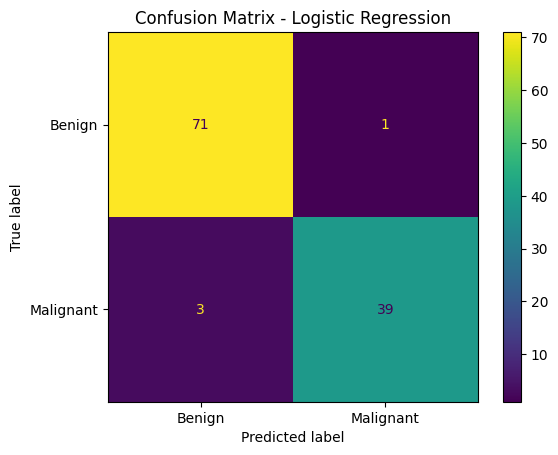

In [11]:
# ============================================
# Cell 21: Confusion Matrix for Best Model
# ============================================
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

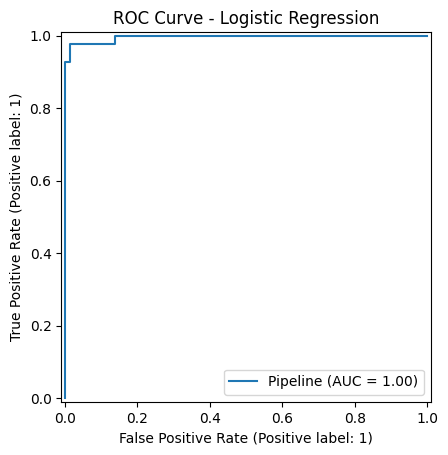

In [12]:
# ============================================
# Cell 22: ROC Curve for Best Model
# ============================================
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"ROC Curve - {best_model_name}")
plt.show()

## 11. XAI Part 1: Logistic Regression Coefficient Importance

In [13]:
# ============================================
# Cell 24: Logistic Regression Coefficient Importance
# ============================================
log_model.fit(X_train, y_train)
log_estimator = log_model.named_steps['model']

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_estimator.coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

print("Top 15 Important Features from Logistic Regression:")
display(coef_df.head(15))

Top 15 Important Features from Logistic Regression:


,Feature,Coefficient,Abs_Coefficient
21,texture_worst,1.434093,1.434093
10,radius_se,1.233325,1.233325
28,symmetry_worst,1.061264,1.061264
7,concave points_mean,0.952813,0.952813
26,concavity_worst,0.911406,0.911406
13,area_se,0.909029,0.909029
15,compactness_se,-0.906925,0.906925
23,area_worst,0.900477,0.900477
20,radius_worst,0.896968,0.896968
6,concavity_mean,0.782298,0.782298


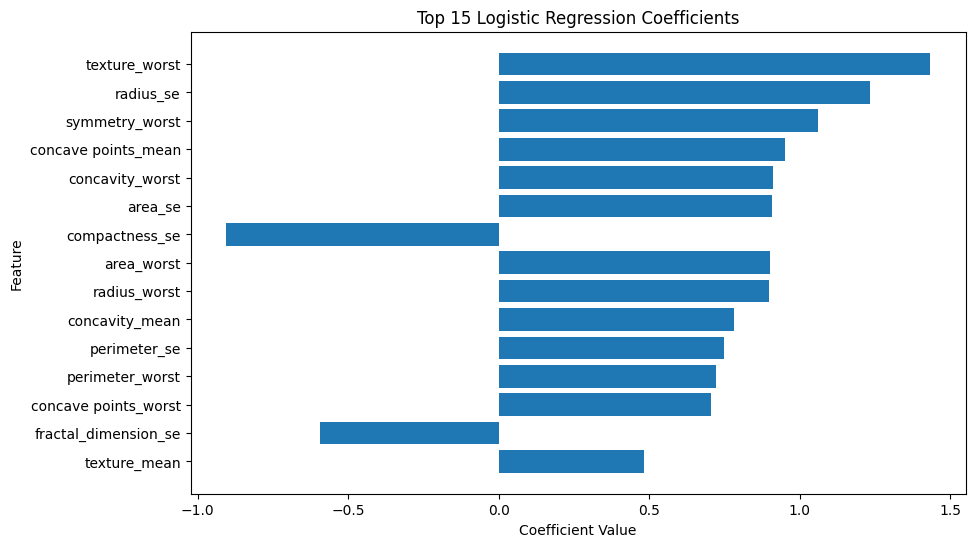

In [14]:
# ============================================
# Cell 25: Plot Logistic Regression Coefficients
# ============================================
top_coef_df = coef_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_coef_df["Feature"], top_coef_df["Coefficient"])
plt.gca().invert_yaxis()
plt.title("Top 15 Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

### Interpretation
- Positive coefficient → increases the chance of **malignant**
- Negative coefficient → decreases the chance of **malignant**

## 12. XAI Part 2: Random Forest Feature Importance

In [15]:
# ============================================
# Cell 28: Train Random Forest for Feature Importance
# ============================================
rf_model.fit(X_train, y_train)

rf_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(rf_importance_df.head(15))

,Feature,Importance
22,perimeter_worst,0.148638
23,area_worst,0.131088
27,concave points_worst,0.112287
20,radius_worst,0.090190
7,concave points_mean,0.089217
2,perimeter_mean,0.061043
0,radius_mean,0.058829
3,area_mean,0.044057
6,concavity_mean,0.043775
26,concavity_worst,0.032596


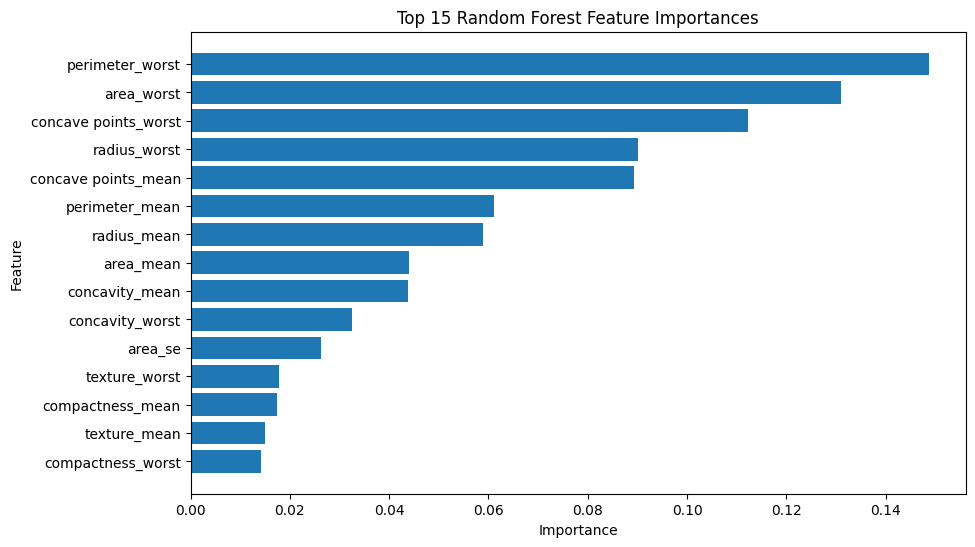

In [16]:
# ============================================
# Cell 29: Plot Random Forest Feature Importance
# ============================================
top_rf_df = rf_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_rf_df["Feature"], top_rf_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 13. XAI Part 3: SHAP Explanation

In [17]:
# ============================================
# Cell 31: Create SHAP Explainer
# ============================================
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

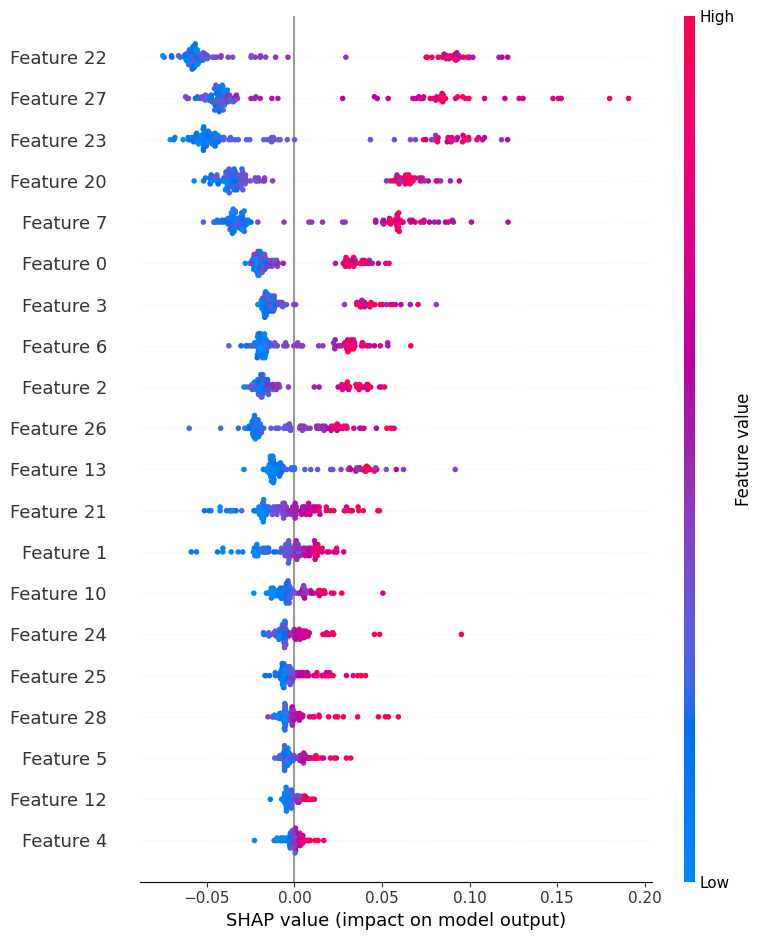

In [20]:
 # ============================================
# Cell 32: SHAP Summary Plot
# ============================================
shap.summary_plot(shap_values[:, :, 1], X_test.values)

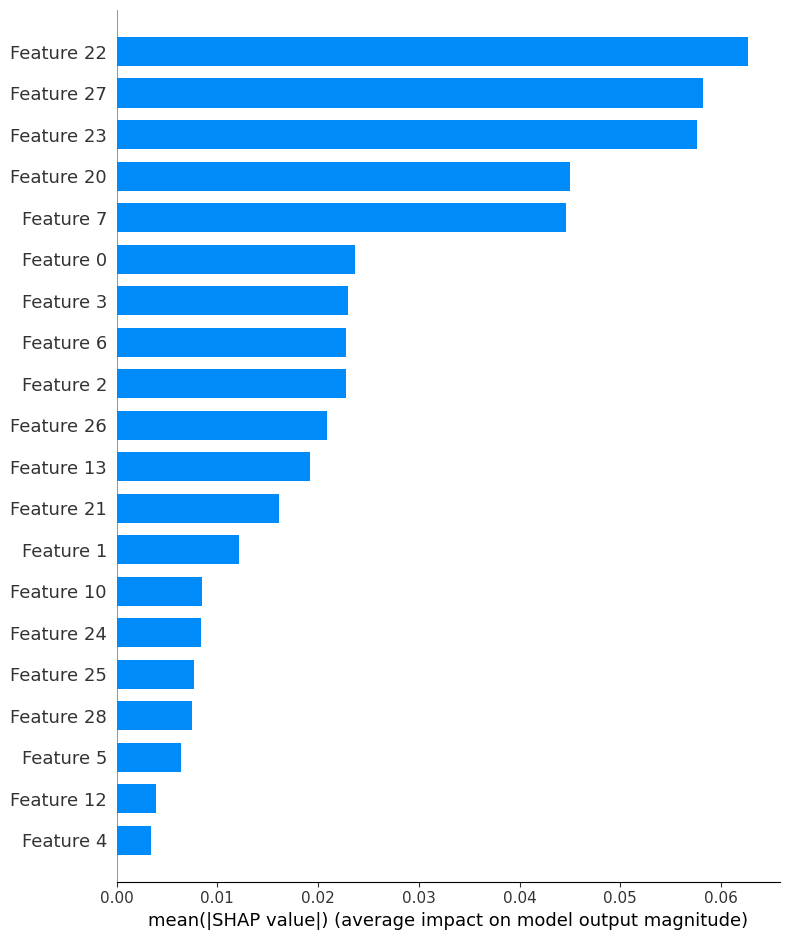

In [22]:
# ============================================
# Cell 33: SHAP Bar Plot
# ============================================
shap.summary_plot(shap_values[:, :, 1], X_test.values, plot_type="bar")

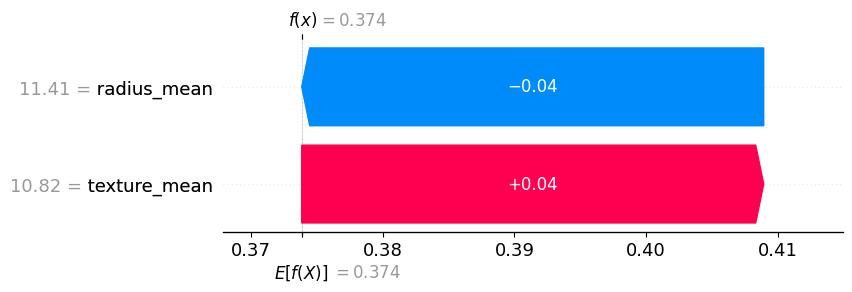

In [23]:
# ============================================
# Cell 34: SHAP Waterfall Plot for One Sample
# ============================================
sample_index = 0

sample_explanation = shap.Explanation(
    values=shap_values[1][sample_index],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[sample_index],
    feature_names=X.columns
)

shap.plots.waterfall(sample_explanation)

In [25]:
# ============================================
# Cell 35: SHAP Force Plot
# ============================================
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[sample_index, :, 1],
    X_test.iloc[sample_index]
)

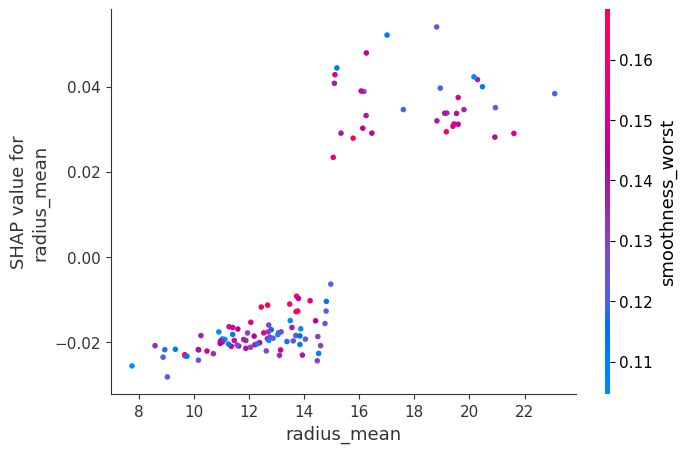

In [28]:
# ============================================
# Cell 36: SHAP Dependence Plot - radius_mean
# ============================================
shap.dependence_plot("radius_mean", shap_values[:, :, 1], X_test)

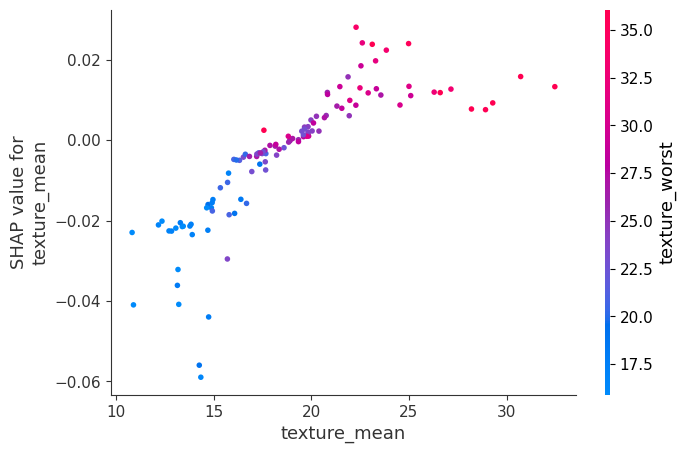

In [30]:
import matplotlib.pyplot as plt
# ============================================
# Cell 37: SHAP Dependence Plot - texture_mean
# ============================================
shap.dependence_plot("texture_mean", shap_values[:, :, 1], X_test)
plt.show()

## 14. XAI Part 4: LIME Explanation

In [31]:
# ============================================
# Cell 39: Create LIME Explainer
# ============================================
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns.tolist(),
    class_names=["Benign", "Malignant"],
    mode="classification"
)

In [32]:
# ============================================
# Cell 40: LIME Explanation for One Sample
# ============================================
sample_index = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[sample_index],
    predict_fn=rf_model.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

In [33]:
# ============================================
# Cell 41: Save LIME Explanation as HTML
# ============================================
lime_exp.save_to_file("lime_breast_cancer_explanation.html")
print("LIME explanation saved successfully.")

LIME explanation saved successfully.


## 15. Show Actual Prediction with XAI

In [34]:
# ============================================
# Cell 43: Explain One Prediction
# ============================================
sample_index = 0
sample_data = X_test.iloc[[sample_index]]

true_label = y_test.iloc[sample_index]
pred_label = rf_model.predict(sample_data)[0]
pred_prob = rf_model.predict_proba(sample_data)[0]

print("Sample Index:", sample_index)
print("True Label :", "Malignant" if true_label == 1 else "Benign")
print("Predicted  :", "Malignant" if pred_label == 1 else "Benign")
print("Probability [Benign, Malignant]:", pred_prob)

Sample Index: 0
True Label : Benign
Predicted  : Benign
Probability [Benign, Malignant]: [0.98826842 0.01173158]


## 16. Save Best Model

In [35]:
# ============================================
# Cell 45: Save Best Model
# ============================================
best_model.fit(X_train, y_train)
joblib.dump(best_model, "best_breast_cancer_model.pkl")
print("Best model saved successfully.")

Best model saved successfully.


## 17. Prediction Function

In [36]:
# ============================================
# Cell 47: Prediction Function
# ============================================
def predict_breast_cancer(model, patient_data):
    patient_df = pd.DataFrame([patient_data], columns=X.columns)
    pred = model.predict(patient_df)[0]
    prob = model.predict_proba(patient_df)[0][1]

    result = "Malignant" if pred == 1 else "Benign"
    return result, prob

In [37]:
# ============================================
# Cell 48: Example Prediction
# ============================================
sample_patient = X.iloc[0].tolist()
result, prob = predict_breast_cancer(best_model, sample_patient)

print("Prediction:", result)
print("Malignant Probability:", round(prob, 4))

Prediction: Malignant
Malignant Probability: 1.0
